# Notebook `test_modulos`

## Este notebook sirve para probar la modulación del código es de prueba nada más. 

In [4]:
import pathlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az 

%load_ext autoreload
%autoreload 2

_cwd = pathlib.Path().resolve()
ROOT = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data'
IDATA_DIR = DATA_DIR / 'idata'

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"IDATA_DIR: {IDATA_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ROOT: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj
DATA_DIR: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj/data
IDATA_DIR: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj/data/idata


In [5]:
df = pd.read_csv(DATA_DIR / 'base_modelo_2019_2023.csv')
print(df.shape)
df.head()

(576, 6)


,estado,anio,surtidas,total,institucion,tipo
0,AGUASCALIENTES,2019,4334260,4338906,IMSS,civil
1,AGUASCALIENTES,2020,3676230,3803608,IMSS,civil
2,AGUASCALIENTES,2021,3874201,4163315,IMSS,civil
3,AGUASCALIENTES,2022,4382755,4557129,IMSS,civil
4,AGUASCALIENTES,2023,4971284,5053481,IMSS,civil


In [6]:
from model_data import preparar_modelo_a, preparar_modelo_c

data_a = preparar_modelo_a(df)
data_c = preparar_modelo_c(df)

print('Modelo A — coords:', {k: len(v) for k, v in data_a['coords'].items()})
print('Modelo C — coords:', {k: len(v) for k, v in data_c['coords'].items()})
print('mask_civil:', data_c['mask_civil'])
print('mask_mil  :', data_c['mask_mil'])
assert data_c['mask_civil'].sum() == 3
assert data_c['mask_mil'].sum() == 2
print('OK — dimensiones esperadas')

Modelo A — coords: {'estado': 32, 'anio': 5, 'institucion': 3, 'tipo': 1}
Modelo C — coords: {'estado': 32, 'anio': 5, 'institucion': 5, 'tipo': 2, 'inst_civil': 3, 'inst_mil': 2}
mask_civil: [ True  True  True False False]
mask_mil  : [False False False  True  True]
OK — dimensiones esperadas


## `models.py` — build_modelo_a / build_modelo_c
Solo construye el grafo del modelo, no samplea — debe correr instantáneo.

In [7]:
from models import build_modelo_a, build_modelo_c

modelo_A = build_modelo_a(data_a)
modelo_C = build_modelo_c(data_c)

print(modelo_A)
print()
print(modelo_C)

## Prior predictive check
Verifica que el Modelo C genera valores razonables de θ antes de samplear.

Sampling: [beta0, dev_civil, dev_mil, eff_anio, eff_estado, eff_tipo, k_obs, sigma_anio, sigma_estado, sigma_inst, sigma_tipo]


theta prior — media: 0.8942
theta prior — rango: 0.0332 0.9991


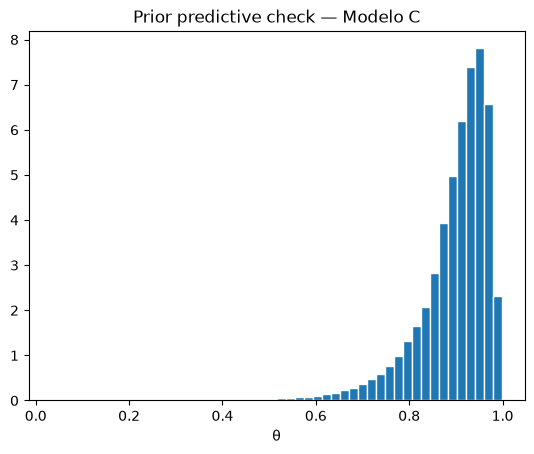

In [8]:
import pymc as pymc

with modelo_C:
    prior_pred = pymc.sample_prior_predictive(samples = 500, random_seed = 42)

theta_prior = prior_pred.prior['theta'].values
print('theta prior — media:', theta_prior.mean().round(4))
print('theta prior — rango:', theta_prior.min().round(4), theta_prior.max().round(4))

plt.hist(theta_prior.flatten(), bins = 50, density = True, edgecolor = 'white')
plt.xlabel('θ')
plt.title('Prior predictive check — Modelo C')
plt.show()


## Muestreo (test rápido)
Pocos draws/tune solo para verificar que el muestreo corre sin error.

In [9]:
with modelo_C:
    idata_test = pymc.sample(
        draws = 2000, tune = 1000, chains = 4,
        target_accept = 0.95, random_seed = 42,
    )

az.summary(idata_test, var_names = ['beta0', 'sigma_estado', 'sigma_anio', 'sigma_tipo', 'sigma_inst'])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, sigma_estado, eff_estado, sigma_anio, eff_anio, sigma_tipo, eff_tipo, sigma_inst, dev_civil, dev_mil]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,2.133,0.001,2.132,2.134,0.000,0.000,9847.0,6564.0,1.0
sigma_estado,0.386,0.052,0.294,0.480,0.000,0.001,17070.0,5525.0,1.0
sigma_anio,0.576,0.129,0.354,0.816,0.001,0.002,18550.0,5251.0,1.0
sigma_tipo,0.870,0.246,0.447,1.319,0.002,0.003,19341.0,6199.0,1.0
sigma_inst,0.412,0.123,0.211,0.638,0.001,0.002,19910.0,5637.0,1.0


Sampling: [k_obs]


Output()

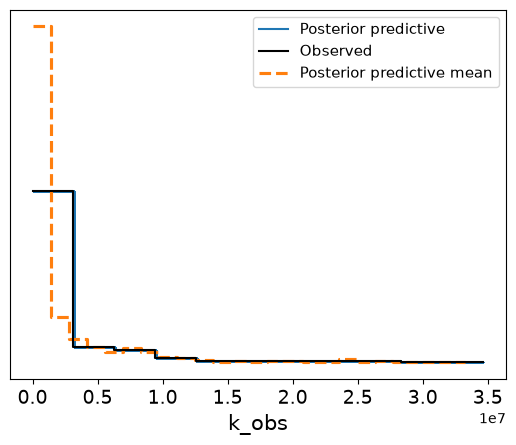

In [10]:
with modelo_C:
    post_pred_test = pymc.sample_posterior_predictive(idata_test, random_seed = 42)

az.plot_ppc(post_pred_test, observed_rug = True)
plt.show()


## `analysis.py` — extracción del posterior


In [11]:
from analysis import (
    extract_posterior,
    brecha_civil_militar,
    ranking_instituciones,
    ranking_estados,
    estados_estructurales,
    escenario,
    declaraciones_politica_publica,
)

post = extract_posterior(idata_test, data_c)

print('Keys en post:', list(post.keys()))
print('Instituciones:', post['insts'])
print('Tipos:', post['tipos'])


Keys en post: ['beta0', 'eff_inst', 'eff_anio', 'eff_estado', 'insts', 'estados', 'anios', 'eff_tipo', 'tipos']
Instituciones: ['IMSS', 'IMSS Bienestar', 'ISSSTE', 'SEDENA', 'SEMAR']
Tipos: ['civil', 'militar']


In [12]:
print('=== Brecha civil/militar ===')
display(brecha_civil_militar(post))

print('=== Ranking instituciones ===')
display(ranking_instituciones(post))


=== Brecha civil/militar ===


,tipo,theta_media,ic_2.5,ic_97.5
0,civil,0.957687,0.957655,0.957719
1,militar,0.758862,0.758529,0.759192


=== Ranking instituciones ===


,institucion,theta_media,ic_2.5,ic_97.5,receta_incompleta
0,ISSSTE,0.975630,0.975606,0.975654,0.024370
1,IMSS,0.951287,0.951270,0.951304,0.048713
2,IMSS Bienestar,0.936831,0.936707,0.936953,0.063169
3,SEMAR,0.768625,0.768115,0.769122,0.231375
4,SEDENA,0.748822,0.748406,0.749249,0.251178


In [13]:
print('=== Ranking estados (primeros 10) ===')
display(ranking_estados(post).head(10))

print('=== Estados estructurales (umbral 0.95) ===')
display(estados_estructurales(post))


=== Ranking estados (primeros 10) ===


,estado,eff_estado_media,ic_2.5,ic_97.5,p_eff_negativo
0,CHIHUAHUA,-0.708564,-0.709464,-0.707686,1.0
1,TABASCO,-0.518693,-0.520634,-0.516762,1.0
2,COAHUILA,-0.382003,-0.383065,-0.380942,1.0
3,OAXACA,-0.380813,-0.382684,-0.378905,1.0
4,MICHOACÁN,-0.348287,-0.349432,-0.347150,1.0
5,CAMPECHE,-0.298862,-0.301384,-0.296295,1.0
6,QUERETARO,-0.273913,-0.275497,-0.272294,1.0
7,ZACATECAS,-0.272630,-0.274444,-0.270773,1.0
8,SAN LUIS POTOSI,-0.270123,-0.271524,-0.268723,1.0
9,DURANGO,-0.249467,-0.250997,-0.247946,1.0


=== Estados estructurales (umbral 0.95) ===


,estado,eff_estado_media,ic_2.5,ic_97.5,p_eff_negativo
0,CHIHUAHUA,-0.708564,-0.709464,-0.707686,1.0
1,TABASCO,-0.518693,-0.520634,-0.516762,1.0
2,COAHUILA,-0.382003,-0.383065,-0.380942,1.0
3,OAXACA,-0.380813,-0.382684,-0.378905,1.0
4,MICHOACÁN,-0.348287,-0.349432,-0.347150,1.0
5,CAMPECHE,-0.298862,-0.301384,-0.296295,1.0
6,QUERETARO,-0.273913,-0.275497,-0.272294,1.0
7,ZACATECAS,-0.272630,-0.274444,-0.270773,1.0
8,SAN LUIS POTOSI,-0.270123,-0.271524,-0.268723,1.0
9,DURANGO,-0.249467,-0.250997,-0.247946,1.0


In [14]:
print('=== Escenario: IMSS, CHIHUAHUA, 2021 ===')
print(escenario(post, inst = 'IMSS', estado = 'CHIHUAHUA', anio = 2021))

print()
print('=== Declaraciones de política pública ===')
for d in declaraciones_politica_publica(post):
    print('-', d['titulo'])
    print(' ', d['detalle'])


=== Escenario: IMSS, CHIHUAHUA, 2021 ===
{'institucion': 'IMSS', 'estado': 'CHIHUAHUA', 'anio': 2021, 'theta_media': np.float64(0.8133264087891491), 'ic_2.5': np.float64(0.8131870027936083), 'ic_97.5': np.float64(0.8134643102792034), 'p_receta_incompleta': np.float64(0.18667359121085092)}

=== Declaraciones de política pública ===
- P(sistema civil > sistema militar) = 100%
  Brecha media de 19.9% puntos porcentuales.
- P(ISSSTE > IMSS en surtimiento) = 100%
  El ISSSTE supera al IMSS con certeza total pese a ser menos discutido públicamente.
- 18 estados con problema estructural confirmado (P(eff_estado<0) > 95%)
  IMSS, ISSSTE e IMSS Bienestar están simultáneamente por debajo del promedio nacional en estos estados.


## `plots.py` — visualizaciones

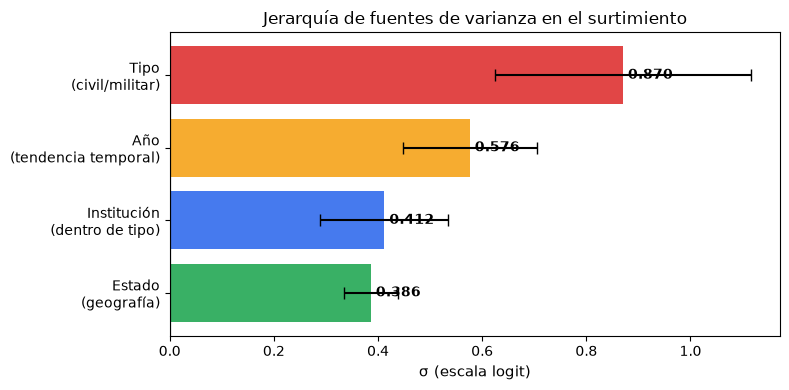

In [15]:
from plots import (
    plot_varianzas,
    plot_brecha_civil_militar,
    plot_ranking_instituciones,
    plot_tendencia_anual,
    plot_ranking_geografico,
    plot_escenarios_criticos,
)
from analysis import theta_posterior

colores_inst = {
    'ISSSTE': '#1d4ed8', 'IMSS': '#2563eb', 'IMSS Bienestar': '#60a5fa',
    'SEDENA': '#b91c1c', 'SEMAR': '#ef4444',
}

plot_varianzas(idata_test)
plt.show()


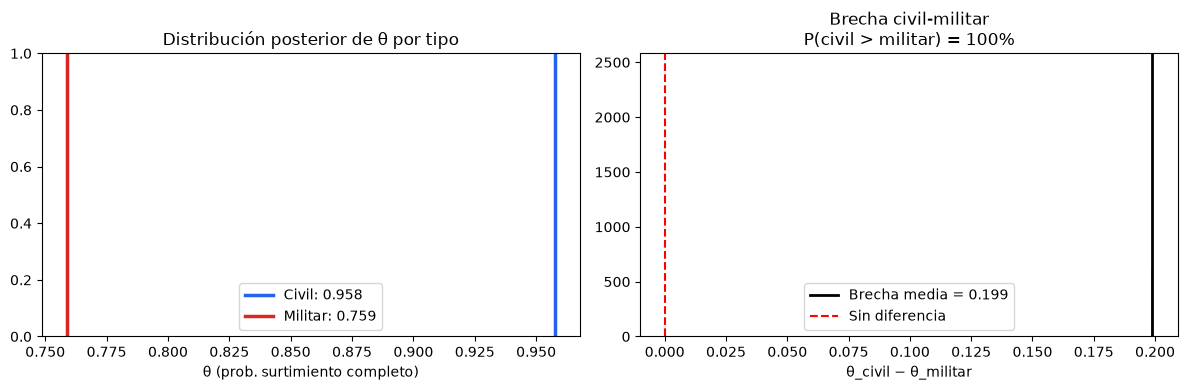

In [16]:
plot_brecha_civil_militar(post)
plt.show()

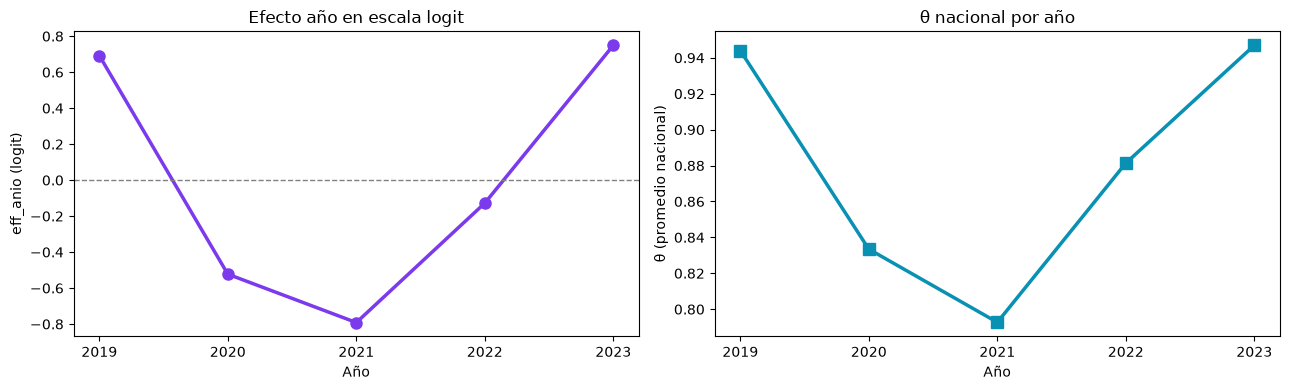

In [17]:
plot_tendencia_anual(post)
plt.show()

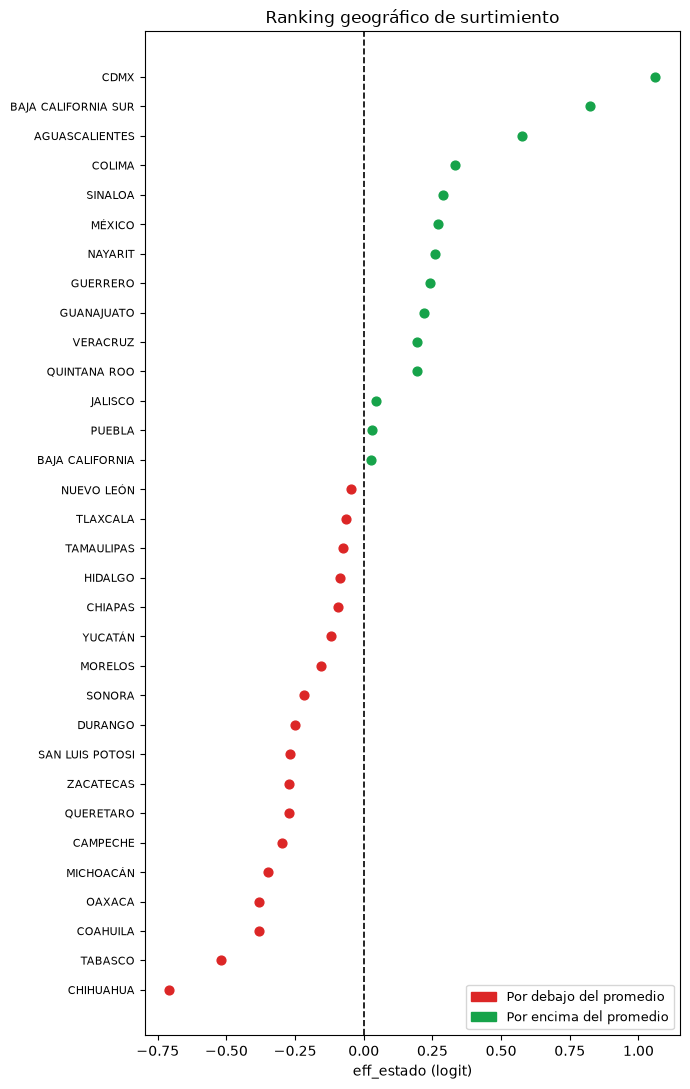

In [18]:
plot_ranking_geografico(post)
plt.show()

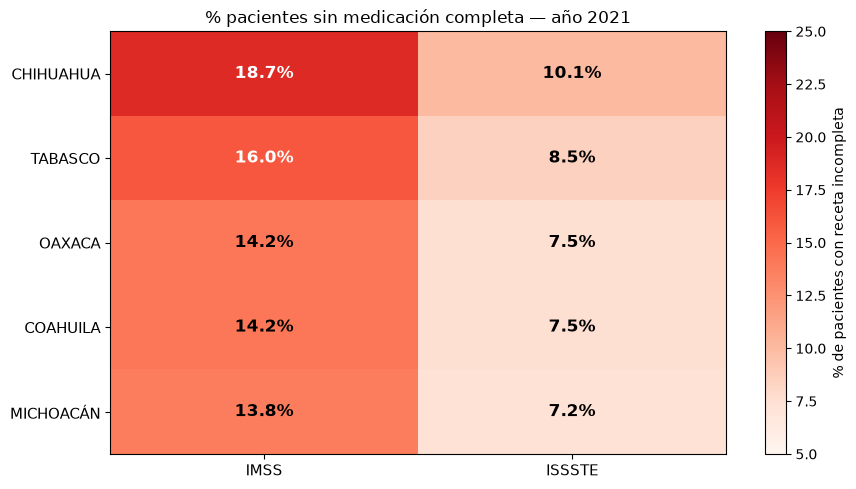

In [19]:
plot_escenarios_criticos(
    post,
    estados = ['CHIHUAHUA', 'TABASCO', 'OAXACA', 'COAHUILA', 'MICHOACÁN'],
    instituciones = ['IMSS', 'ISSSTE'],
    anio = 2021,
    theta_posterior_fn = theta_posterior,
)
plt.show()


## Smoke test final
Si todas las celdas anteriores corrieron sin error, los módulos están listos.

In [20]:
print('✓ model_data  — OK')
print('✓ models      — OK')
print('✓ analysis    — OK')
print('✓ plots       — OK')
print()
print('Todos los módulos funcionan correctamente.')

✓ model_data  — OK
✓ models      — OK
✓ analysis    — OK
✓ plots       — OK

Todos los módulos funcionan correctamente.
